## LeNet-5

- CNN 아키텍처 중 하나
- 심층 학습의 기초를 마련한 고전적인 모델
- Yuan LeCun 
- 주로 손으로 쓴 문자와 기계로 인쇄된 문자를 인식하는데 사용

- 단순하고 직관적 아키텍처 
- 5개의 학습 가능한 층

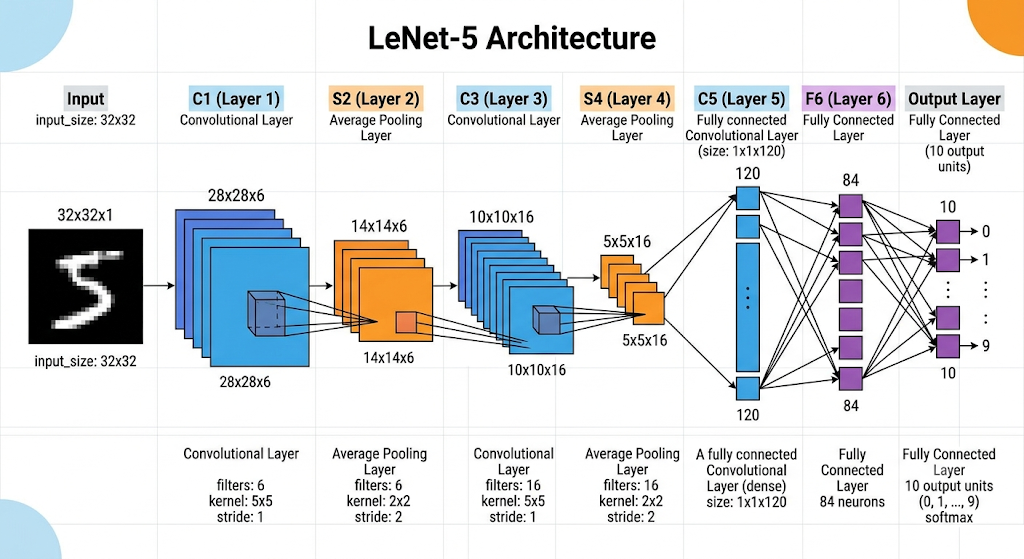


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary

In [2]:
x = torch.randn(1, 1, 32, 32) #1channel, 32x32 image
x

tensor([[[[ 0.3325, -1.0677,  0.4688,  ...,  0.8445,  1.2429,  0.1697],
          [ 0.0992,  0.5803, -0.7996,  ..., -0.9529,  0.9362,  0.4397],
          [-0.6249,  0.8176, -1.6638,  ...,  1.6338, -0.7211,  0.9606],
          ...,
          [-0.4329, -1.2229,  1.4102,  ...,  0.2458,  1.4215, -0.9963],
          [-1.7542, -0.7600, -0.7632,  ..., -0.1820,  0.5822,  0.6577],
          [-0.3054,  0.4886,  0.0388,  ...,  0.0644, -2.3244, -0.8723]]]])

In [3]:
#첫번째 합성곱 층(c1)
conv1 = nn.Conv2d(1, 6, kernel_size=5)#stride=1, padding=0
x = torch.tanh(conv1(x))
print(x.shape) #1, 6, 28, 28

torch.Size([1, 6, 28, 28])


# padding 이 없을 때 출력 크기 

$$
출력 크기 = \frac{입력 크기 - 필터 크기}{스트라이드} + 1
$$

입력 크기 32x32, 필터 크기 5x5, 스트라이드가 1인 경우

출력 높이 = $\frac{32-5}{1} + 1 = 28$, 출력 너비 $\frac{32-5}{1} + 1 = 28 $

6개의 필터를 사용하므로, 출력 특징 맵의 깊이는 6이 된다. 

In [4]:
#첫번째 폴링층(s2), 입력데이터의 크기를 줄인다.
pool = nn.AvgPool2d(kernel_size=2, stride=2)

x = pool(x)
print(x.shape) #1, 6, 14, 14

torch.Size([1, 6, 14, 14])


## 풀링층 연산 

$출력 크기 = \frac{입력 크기}{스트라이드} = \frac{28}{2} = 14  $. 

$\therefore 14\times14\times6 $

In [5]:
#두번째 합성곱 층(c3)
conv2 = nn.Conv2d(6, 16, kernel_size=5)

x = torch.tanh(conv2(x))
print(x.shape)

torch.Size([1, 16, 10, 10])


In [6]:
#두번째 폴링층 
x = pool(x)
print(x.shape)

torch.Size([1, 16, 5, 5])


In [7]:
conv3 = nn.Conv2d(16, 120, kernel_size=5)

x = torch.tanh(conv3(x))
print(x.shape)

torch.Size([1, 120, 1, 1])


In [8]:
#완전 연결층(fc1)
# Flatten (벡터로 변환)
x_flatten = x.view(-1, 120) #-1: 자동으로 재치 크기를 계산, 120: 가 샘플 피처(특징) 수 
print(x_flatten.shape)

# 첫 번째 Fully Connected 레이어 정의
fc1 = nn.Linear(120, 84)

# 첫 번째 Fully Connected 레이어 통과
x = torch.tanh(fc1(x_flatten))
print(x.shape)

torch.Size([1, 120])
torch.Size([1, 84])


In [9]:
#fully connected layer 2
fc2 = nn.Linear(84, 10) #fully_connected layer
x = fc2(x)
print(x.shape)

torch.Size([1, 10])


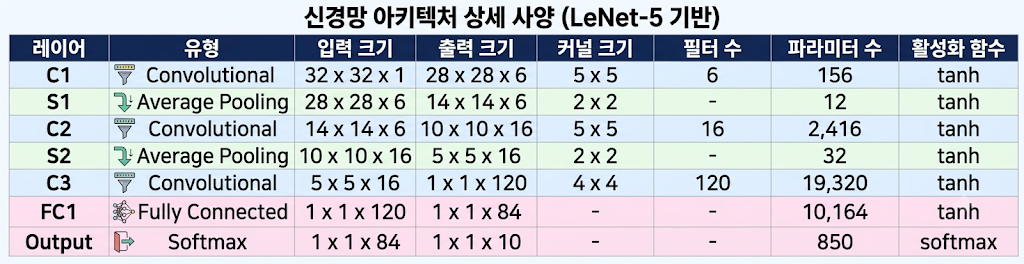

In [10]:
#LeNet Model

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5)
        self.fc1 = nn.Linear(120, 84)
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool(x)
        x = torch.tanh(self.conv2(x))
        x = self.pool(x)
        x = torch.tanh(self.conv3(x))
        x = x.view(-1, 120)
        x = torch.tanh(self.fc1(x))
        x = self.fc2(x)
        return x

In [11]:
model = LeNet5()
summary(model, (1, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 28, 28]             156
         AvgPool2d-2            [-1, 6, 14, 14]               0
            Conv2d-3           [-1, 16, 10, 10]           2,416
         AvgPool2d-4             [-1, 16, 5, 5]               0
            Conv2d-5            [-1, 120, 1, 1]          48,120
            Linear-6                   [-1, 84]          10,164
            Linear-7                   [-1, 10]             850
Total params: 61,706
Trainable params: 61,706
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.06
Params size (MB): 0.24
Estimated Total Size (MB): 0.30
----------------------------------------------------------------


In [12]:
#입력 데이터 생성 및 손실 계산 
# 입력 데이터 생성
x = torch.randn(1, 1, 32, 32)

# 순전파
logits = model(x)
print(logits.shape)  # (1, 10)

# 손실 함수 정의 및 사용
criterion = nn.CrossEntropyLoss()
target = torch.tensor([1])  # 예시 정답 레이블
loss = criterion(logits, target)
print(loss)

torch.Size([1, 10])
tensor(2.2471, grad_fn=<NllLossBackward0>)
